In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             roc_auc_score, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14

# Load data
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nAttrition breakdown:')
print(df['Attrition'].value_counts())
print(f'\nAttrition rate: '
      f'{(df["Attrition"]=="Yes").mean()*100:.1f}%')
df.head()

Rows: 1,470 | Columns: 35

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


=== ATTRITION COST ANALYSIS ===
Total Employees:      1,470
Employees Who Left:   237
Attrition Rate:       16.1%
Avg Monthly Salary:   $6,503

Estimated Annual Cost of Attrition:
  Conservative (50%): $9,247,168
  Aggressive (200%):  $36,988,673


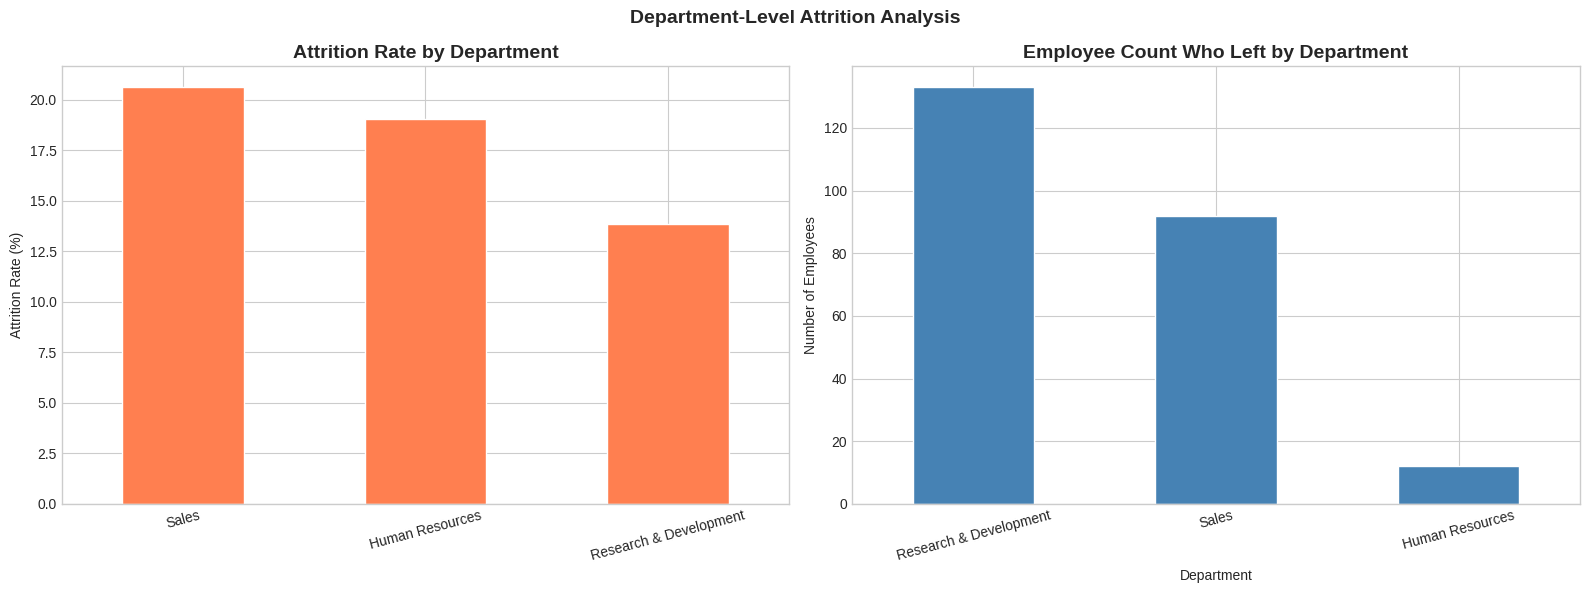

In [2]:
# Convert attrition to binary
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

# Overall attrition stats
total_employees = len(df)
attrition_count = df['Attrition_Binary'].sum()
attrition_rate  = df['Attrition_Binary'].mean() * 100
avg_salary      = df['MonthlyIncome'].mean()

# Cost calculation
# Industry standard: replacing an employee costs
# 50-200% of annual salary
replacement_cost_low  = avg_salary * 12 * 0.5
replacement_cost_high = avg_salary * 12 * 2.0
total_cost_low  = attrition_count * replacement_cost_low
total_cost_high = attrition_count * replacement_cost_high

print('=== ATTRITION COST ANALYSIS ===')
print(f'Total Employees:      {total_employees:,}')
print(f'Employees Who Left:   {attrition_count:,}')
print(f'Attrition Rate:       {attrition_rate:.1f}%')
print(f'Avg Monthly Salary:   ${avg_salary:,.0f}')
print(f'\nEstimated Annual Cost of Attrition:')
print(f'  Conservative (50%): ${total_cost_low:,.0f}')
print(f'  Aggressive (200%):  ${total_cost_high:,.0f}')

# Attrition by department
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept_attrition = df.groupby('Department')['Attrition_Binary']\
                   .mean() * 100
dept_attrition.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='coral',
    edgecolor='white')
axes[0].set_title('Attrition Rate by Department',
                  fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# Attrition count by department
dept_count = df[df['Attrition']=='Yes']\
               .groupby('Department').size()
dept_count.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue',
    edgecolor='white')
axes[1].set_title('Employee Count Who Left by Department',
                  fontweight='bold')
axes[1].set_ylabel('Number of Employees')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Department-Level Attrition Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig01_department_attrition.png',
            dpi=150, bbox_inches='tight')
plt.show()

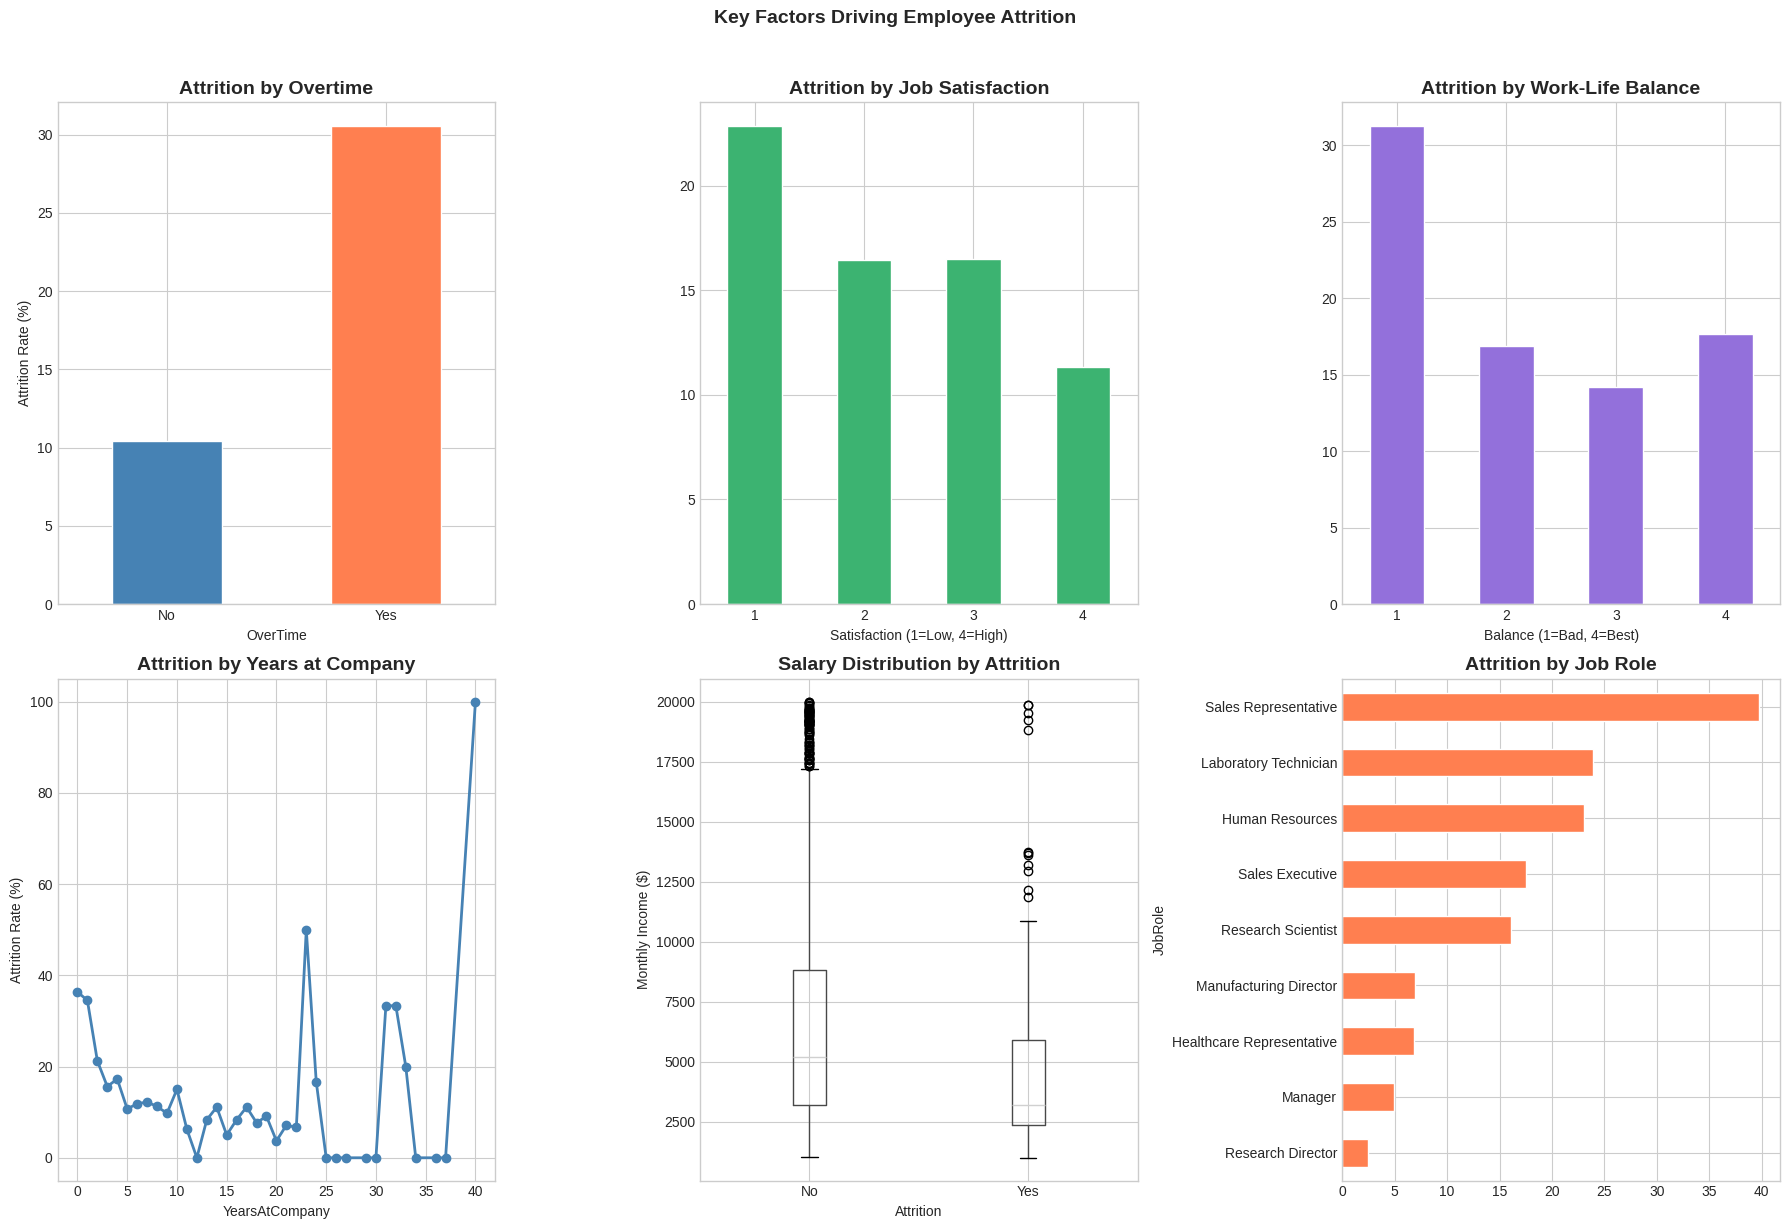

In [3]:
# Key factors driving attrition
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Overtime
overtime = df.groupby('OverTime')['Attrition_Binary']\
             .mean() * 100
overtime.plot(kind='bar', ax=axes[0,0],
              color=['steelblue','coral'],
              edgecolor='white')
axes[0,0].set_title('Attrition by Overtime',
                    fontweight='bold')
axes[0,0].set_ylabel('Attrition Rate (%)')
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Job satisfaction
job_sat = df.groupby('JobSatisfaction')['Attrition_Binary']\
            .mean() * 100
job_sat.plot(kind='bar', ax=axes[0,1],
             color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Attrition by Job Satisfaction',
                    fontweight='bold')
axes[0,1].set_xlabel('Satisfaction (1=Low, 4=High)')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Work-life balance
wlb = df.groupby('WorkLifeBalance')['Attrition_Binary']\
        .mean() * 100
wlb.plot(kind='bar', ax=axes[0,2],
         color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Attrition by Work-Life Balance',
                    fontweight='bold')
axes[0,2].set_xlabel('Balance (1=Bad, 4=Best)')
axes[0,2].tick_params(axis='x', rotation=0)

# 4. Years at company
years_attrition = df.groupby('YearsAtCompany')\
                    ['Attrition_Binary'].mean() * 100
years_attrition.plot(kind='line', ax=axes[1,0],
                     color='steelblue', linewidth=2,
                     marker='o')
axes[1,0].set_title('Attrition by Years at Company',
                    fontweight='bold')
axes[1,0].set_ylabel('Attrition Rate (%)')

# 5. Monthly income distribution
df.boxplot(column='MonthlyIncome',
           by='Attrition', ax=axes[1,1])
axes[1,1].set_title('Salary Distribution by Attrition',
                    fontweight='bold')
axes[1,1].set_xlabel('Attrition')
axes[1,1].set_ylabel('Monthly Income ($)')

# 6. Job role attrition
role_attrition = df.groupby('JobRole')['Attrition_Binary']\
                   .mean() * 100
role_attrition.sort_values(ascending=True).plot(
    kind='barh', ax=axes[1,2],
    color='coral', edgecolor='white')
axes[1,2].set_title('Attrition by Job Role',
                    fontweight='bold')

plt.suptitle('Key Factors Driving Employee Attrition',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig02_attrition_factors.png',
            dpi=150, bbox_inches='tight')
plt.show()

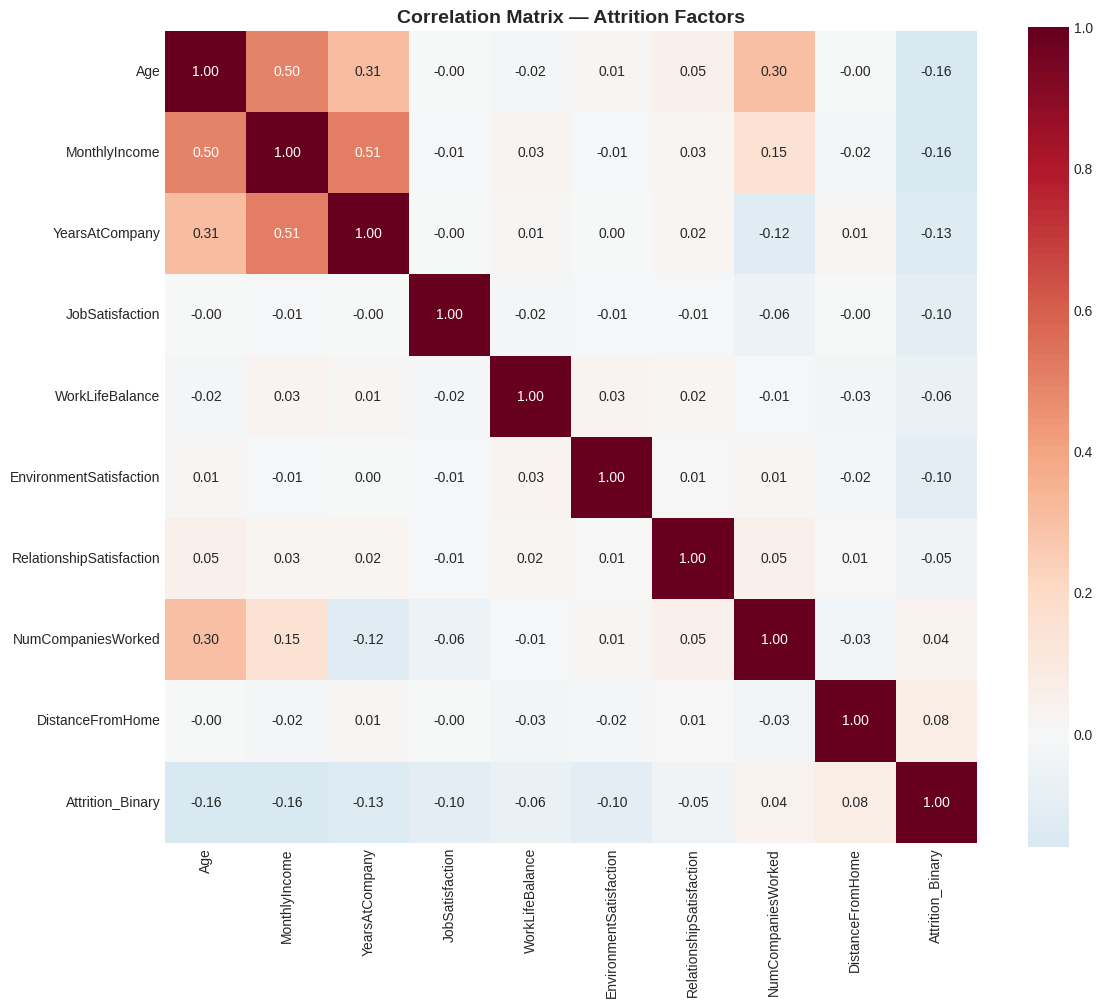

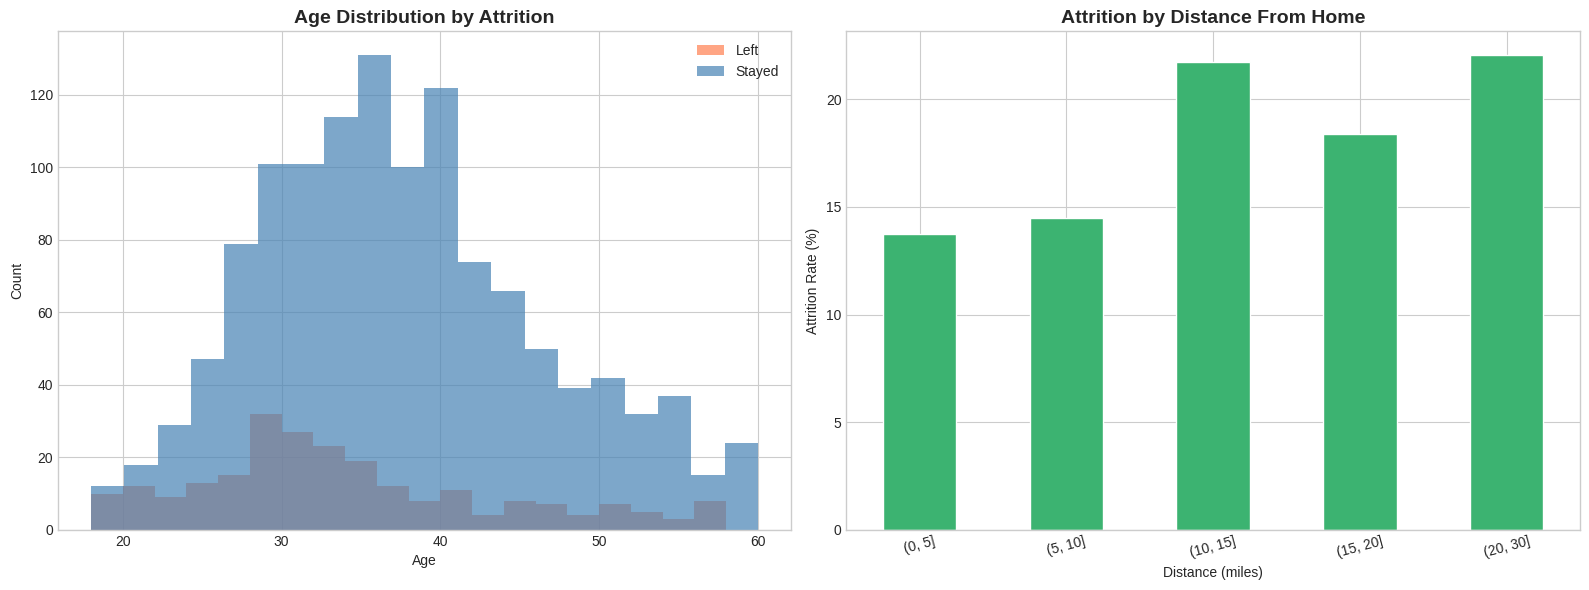

In [4]:
# Correlation heatmap
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                'JobSatisfaction', 'WorkLifeBalance',
                'EnvironmentSatisfaction',
                'RelationshipSatisfaction',
                'NumCompaniesWorked', 'DistanceFromHome',
                'Attrition_Binary']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            square=True)
plt.title('Correlation Matrix — Attrition Factors',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig03_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Age vs attrition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age distribution
df[df['Attrition']=='Yes']['Age'].hist(
    bins=20, ax=axes[0], alpha=0.7,
    color='coral', label='Left')
df[df['Attrition']=='No']['Age'].hist(
    bins=20, ax=axes[0], alpha=0.7,
    color='steelblue', label='Stayed')
axes[0].set_title('Age Distribution by Attrition',
                  fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Distance from home
dist_attrition = df.groupby(
    pd.cut(df['DistanceFromHome'],
           bins=[0,5,10,15,20,30])
)['Attrition_Binary'].mean() * 100
dist_attrition.plot(kind='bar', ax=axes[1],
                    color='mediumseagreen',
                    edgecolor='white')
axes[1].set_title('Attrition by Distance From Home',
                  fontweight='bold')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig04_age_distance.png',
            dpi=150, bbox_inches='tight')
plt.show()

=== RANDOM FOREST RESULTS ===
ROC-AUC Score: 0.7574

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



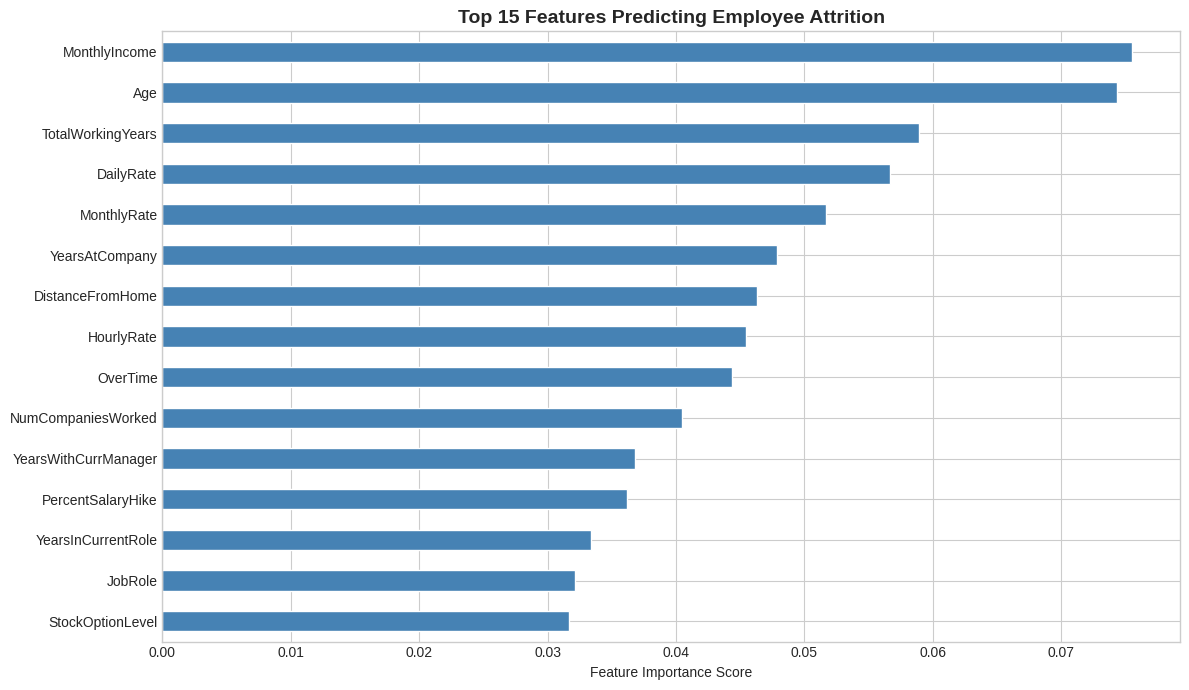


=== RISK SEGMENTATION ===
Risk_Level
Low Risk       1200
High Risk       193
Medium Risk      28
Name: count, dtype: int64

✅ Clean file saved for Tableau and Power BI!


In [5]:
# Encode categorical variables
df_ml = df.copy()
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features and target
feature_cols = [c for c in df_ml.columns
                if c not in ['Attrition', 'Attrition_Binary',
                             'EmployeeNumber',
                             'EmployeeCount',
                             'StandardHours', 'Over18']]
X = df_ml[feature_cols]
y = df_ml['Attrition_Binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100, random_state=42,
    class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_auc  = roc_auc_score(y_test,
          rf.predict_proba(X_test)[:,1])

print('=== RANDOM FOREST RESULTS ===')
print(f'ROC-AUC Score: {rf_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['Stayed', 'Left']))

# Feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
importance.sort_values().plot(
    kind='barh', ax=ax,
    color='steelblue', edgecolor='white')
plt.title('Top 15 Features Predicting Employee Attrition',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('fig05_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Identify high risk employees
df['Attrition_Prob'] = rf.predict_proba(
    df_ml[feature_cols])[:,1]
df['Risk_Level'] = pd.cut(
    df['Attrition_Prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

print('\n=== RISK SEGMENTATION ===')
print(df['Risk_Level'].value_counts())

# Save for Tableau and Power BI
df.to_csv('hr_attrition_clean.csv', index=False)
print('\n✅ Clean file saved for Tableau and Power BI!')